# Классификация трафика

### Описание задачи
Сервисы автоматизированного сбора данных собирают данные из объявлений Авито: отслеживают цены, выгружают контакты и сводки. Задача - построить ML-модель, которая по событиям внутри суточного окна наблюдения присваивает каждой `cookie_id` оценку вероятности от 0 до 1 (`target = 1` - бот, `target = 0` - человек).

* **Целевая метрика**: $P@R \ge 0.70$
* **Ограничение**: Признаки извлекаются внутри окна наблюдения, т.е. $window\_start\_ts \le event\_ts < window\_end\_ts$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import seaborn as sns
from catboost import CatBoostClassifier

from metric import pr_curve, precision_at_recall, recall_at_fpr

SECONDS_PER_DAY = 86400.0  # Секунд в сутках (24 ч * 60 мин * 60 сек)
SECONDS_PER_MINUTE = 60.0  # Секунд в минуте
EPSILON = 1e-5  # Малое число для предотвращения деления на 0

RANDOM_STATE = 42  # Сид для воспроизводимости
np.random.seed(RANDOM_STATE)

## 1. EDA

Загрузим входные CSV-файлы и изучим исходные данные

In [2]:
train_meta = pl.read_csv("data/train.csv")
test_meta = pl.read_csv("data/test.csv")
events = pl.read_csv("data/events.csv.gz")

print(f"Размер train_meta: {train_meta.shape}")
print(f"Размер test_meta:  {test_meta.shape}")
print(f"Размер events:     {events.shape}")
print(f"Доля ботов в train: {train_meta['target'].mean():.4f}")

train_meta.head(10)

Размер train_meta: (11091, 5)
Размер test_meta:  (4909, 4)
Размер events:     (328905, 14)
Доля ботов в train: 0.0811


cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
str,str,str,str,i64
"""ck_54a059eb7d3ea68b""","""2025-11-21 09:30:41""","""2026-04-06""","""2026-04-07""",0
"""ck_7e4de46eeab82974""","""2025-09-23 10:10:24""","""2026-04-06""","""2026-04-07""",0
"""ck_9320229ef6304522""","""2026-03-04 00:08:02""","""2026-04-06""","""2026-04-07""",0
"""ck_30ccd25bc1714ed9""","""2026-04-05 10:52:40""","""2026-04-06""","""2026-04-07""",0
"""ck_a77c5f05948cdeef""","""2026-01-01 03:54:35""","""2026-04-06""","""2026-04-07""",0
"""ck_ea6f843af2292fec""","""2026-02-28 17:39:05""","""2026-04-06""","""2026-04-07""",0
"""ck_e38634dc2f188574""","""2025-11-02 16:17:05""","""2026-04-06""","""2026-04-07""",0
"""ck_ad7f01440bb250d1""","""2026-04-05 15:53:42""","""2026-04-06""","""2026-04-07""",0
"""ck_a7a58d28a4482bdc""","""2025-08-05 13:31:50""","""2026-04-06""","""2026-04-07""",0


In [3]:
events.head(10)

cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
str,str,i64,str,str,str,i64,str,str,str,str,i64,i64,i64
"""ck_5efbea1befdefe1b""","""2026-04-26 09:11:24""",200,"""item_view""","""desktop""","""Mozilla/5.0 (Macintosh; Intel …",1027450,"""elektronika""","""kaliningrad""","""pro""",null,null,null,null
"""ck_c4ca1434f3778f1d""","""2026-04-20 14:04:31""",100,"""search_results_view""","""web""","""Mozilla/5.0 (Windows NT 10.0; …",null,"""telefony""","""habarovsk""",null,"""iphone 13 128""",4,null,null
"""ck_d274382b19488771""","""2026-04-13 12:02:56""",200,"""item_view""","""WEB""","""Mozilla/5.0 (Windows NT 10.0; …",1048743,"""kvartiry_prodazha""","""kirov""","""private""",null,null,675,276
"""ck_fbbed2ff14944ce9""","""2026-04-08 06:12:14""",100,"""search_results_view""","""web""","""Mozilla/5.0 (Macintosh; Intel …",null,"""bytovaya_tehnika""","""novosibirsk""",null,"""пылесос dyson""",2,null,null
"""ck_56cc15c7c634cb9f""","""2026-04-12 17:16:05""",100,"""search_results_view""","""WEB""","""Mozilla/5.0 (Macintosh; Intel …",null,"""odezhda""","""sankt-peterburg""",null,"""костюм мужской""",2,null,null
"""ck_6e98fe733ea437fa""","""2026-04-10 00:02:49""",900,"""captcha_shown""","""Web""","""Mozilla/5.0 (Macintosh; Intel …",null,null,null,null,null,null,null,null
"""ck_61176dafb33b2d8a""","""2026-04-20 11:34:58""",210,"""photo_swipe""","""Android""","""Avito/122.0 (Android 11; M2101…",1022754,"""zhivotnye""","""ekaterinburg""",null,null,null,null,null
"""ck_f80d85f038cdacee""","""2026-04-11 16:08:12""",200,"""item_view""","""desktop""","""Mozilla/5.0 (Windows NT 10.0; …",1000845,"""bytovaya_tehnika""","""sankt-peterburg""","""private""",null,null,null,null
"""ck_e4f046f721d10f81""","""2026-04-10 16:50:05""",200,"""item_view""","""IOS""","""Mozilla/5.0 (iPhone; CPU iPhon…",1055188,"""telefony""","""ekaterinburg""","""pro""",null,null,null,null


In [4]:
print("Распределение типов событий:")
events["event_name"].value_counts()

Распределение типов событий:


event_name,count
str,u32
"""captcha_shown""",7928
"""photo_swipe""",36517
"""contact_phone_show""",11316
"""item_view""",120817
"""contact_chat_open""",6125
"""search_results_view""",100402
"""favorite_add""",19049
"""login""",6267
"""contact_message_sent""",3081


In [5]:
print("Пропуски в колонках events:")
events.null_count()

Пропуски в колонках events:


cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,114597,32920,23793,133853,228503,228503,220365,220365


## 2. Фильтрация событий по суточным окнам наблюдения

Признаки должны строиться исключительно по событиям, происходящим в интервале $[window\_start\_ts, window\_end\_ts)$. Создадим функцию фильтрации для исключения событий за пределами окон

In [6]:
def filter_events_in_window(
    events_df: pl.DataFrame, meta_df: pl.DataFrame
) -> pl.DataFrame:
    events = events_df.with_columns(pl.col("event_ts").str.to_datetime())
    meta = meta_df.with_columns(
        [
            pl.col("window_start_ts").str.to_datetime(),
            pl.col("window_end_ts").str.to_datetime(),
        ]
    )

    ev_win = events.join(
        meta.select(["cookie_id", "window_start_ts", "window_end_ts"]),
        on="cookie_id",
        how="inner",
    ).filter(
        (pl.col("event_ts") >= pl.col("window_start_ts"))
        & (pl.col("event_ts") < pl.col("window_end_ts"))
    )
    return ev_win

In [7]:
events_train = filter_events_in_window(events, train_meta)
events_test = filter_events_in_window(events, test_meta)


In [8]:
print(f"Событий в train: {len(events_train)} из {len(events)}")
print(f"Событий в test:  {len(events_test)} из {len(events)}")


Событий в train: 198436 из 328905
Событий в test:  89690 из 328905


In [9]:
events_train.head(10)


cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,window_start_ts,window_end_ts
str,datetime[μs],i64,str,str,str,i64,str,str,str,str,i64,i64,i64,datetime[μs],datetime[μs]
"""ck_d274382b19488771""",2026-04-13 12:02:56,200,"""item_view""","""WEB""","""Mozilla/5.0 (Windows NT 10.0; …",1048743,"""kvartiry_prodazha""","""kirov""","""private""",null,null,675,276,2026-04-13 00:00:00,2026-04-14 00:00:00
"""ck_fbbed2ff14944ce9""",2026-04-08 06:12:14,100,"""search_results_view""","""web""","""Mozilla/5.0 (Macintosh; Intel …",null,"""bytovaya_tehnika""","""novosibirsk""",null,"""пылесос dyson""",2,null,null,2026-04-08 00:00:00,2026-04-09 00:00:00
"""ck_56cc15c7c634cb9f""",2026-04-12 17:16:05,100,"""search_results_view""","""WEB""","""Mozilla/5.0 (Macintosh; Intel …",null,"""odezhda""","""sankt-peterburg""",null,"""костюм мужской""",2,null,null,2026-04-12 00:00:00,2026-04-13 00:00:00
"""ck_f80d85f038cdacee""",2026-04-11 16:08:12,200,"""item_view""","""desktop""","""Mozilla/5.0 (Windows NT 10.0; …",1000845,"""bytovaya_tehnika""","""sankt-peterburg""","""private""",null,null,null,null,2026-04-11 00:00:00,2026-04-12 00:00:00
"""ck_e4f046f721d10f81""",2026-04-10 16:50:05,200,"""item_view""","""IOS""","""Mozilla/5.0 (iPhone; CPU iPhon…",1055188,"""telefony""","""ekaterinburg""","""pro""",null,null,null,null,2026-04-10 00:00:00,2026-04-11 00:00:00
"""ck_ebd93c2cf4ecc44c""",2026-04-13 15:29:38,100,"""search_results_view""","""Web""","""Mozilla/5.0 (Windows NT 10.0; …",null,"""hobbi""","""ekaterinburg""",null,"""лыжи""",1,null,null,2026-04-13 00:00:00,2026-04-14 00:00:00
"""ck_7f68cc69f1340d17""",2026-04-15 20:38:42,210,"""photo_swipe""","""android""","""Mozilla/5.0 (Linux; Android 14…",1038475,"""noutbuki""","""bryansk""","""private""",null,null,null,null,2026-04-15 00:00:00,2026-04-16 00:00:00
"""ck_fe1ef1b89fe43fbc""",2026-04-10 01:45:25,200,"""item_view""","""android""","""Avito/120.0 (Android 12; M2101…",1051798,"""hobbi""","""samara""","""private""",null,null,null,null,2026-04-10 00:00:00,2026-04-11 00:00:00
"""ck_e022d250ef8ecaa7""",2026-04-11 18:31:31,200,"""item_view""","""Android""","""Mozilla/5.0 (Linux; Android 13…",1055286,"""zapchasti""","""tolyatti""","""private""",null,null,null,null,2026-04-11 00:00:00,2026-04-12 00:00:00


## 3. Построение baseline

Для получения точки отсчёта построим простейший baseline (как в `quickstart.ipynb`):
1. Считаем всего 2 признака: общее число событий (`n_events`) и число уникальных объявлений (`item_nunique`)
2. Для честной оценки разбиваем `train` по времени (`window_start_ts >= '2026-04-17'`), так как тестовая выборка хронологически идет после обучающей

In [10]:
def build_basic_features(ev_df: pl.DataFrame, meta_df: pl.DataFrame) -> pd.DataFrame:
    g = ev_df.group_by("cookie_id").agg(
        [pl.len().alias("n_events"), pl.col("item_id").n_unique().alias("item_nunique")]
    )
    res = meta_df.select(["cookie_id", "window_start_ts", "target"]).join(
        g, on="cookie_id", how="left"
    )
    res = res.with_columns(
        [pl.col("n_events").fill_null(0), pl.col("item_nunique").fill_null(0)]
    )
    return res.to_pandas()

In [11]:
base_train = build_basic_features(events_train, train_meta)

base_train.head(10)


,cookie_id,window_start_ts,target,n_events,item_nunique
0,ck_54a059eb7d3ea68b,2026-04-06,0,7,5
1,ck_7e4de46eeab82974,2026-04-06,0,41,20
2,ck_9320229ef6304522,2026-04-06,0,36,20
3,ck_30ccd25bc1714ed9,2026-04-06,0,21,11
4,ck_a77c5f05948cdeef,2026-04-06,0,29,17
5,ck_ea6f843af2292fec,2026-04-06,0,19,11
6,ck_e38634dc2f188574,2026-04-06,0,10,7
7,ck_ad7f01440bb250d1,2026-04-06,0,24,8
8,ck_a7a58d28a4482bdc,2026-04-06,0,5,3
9,ck_e00e1e6c2a2ab4ac,2026-04-06,1,20,10


In [12]:
# Сплит
is_val_base = pd.to_datetime(base_train["window_start_ts"]) >= "2026-04-17"
X_trainain_b, y_trainain_b = (
    base_train.loc[~is_val_base, ["n_events", "item_nunique"]],
    base_train.loc[~is_val_base, "target"].values,
)
X_val_base, y_val_base = (
    base_train.loc[is_val_base, ["n_events", "item_nunique"]],
    base_train.loc[is_val_base, "target"].values,
)


In [13]:
base_model = CatBoostClassifier(
    iterations=200, depth=4, verbose=0, random_seed=RANDOM_STATE
)

base_model.fit(X_trainain_b, y_trainain_b)


CatBoostClassifier(depth=4, iterations=200, random_seed=42, verbose=0)

In [14]:
base_preds = base_model.predict_proba(X_val_base)[:, 1]

base_score = precision_at_recall(y_val_base, base_preds)

print(f"baseline P@R>=0.70 на валидации: {base_score:.4f}")


baseline P@R>=0.70 на валидации: 0.1225


$P@R \approx 0.1225$ ничуть не лучше случайного угадывания

## 4. Feature Engineering

Построим гипотезы о разнице между поведением человека и парсера и выделим признаковые блоки.

### 4.1. Временные интервалы и сессионная динамика

* **Гипотеза**: Автоматизированные боты отправляют запросы батчами с минимальной задержкой ($\Delta t < 0.05\text{s}$) либо с жестко заданным одинаковым таймером. Люди же не обладают такой автоматизацией

In [15]:
def extract_timing_features(ev_df: pl.DataFrame, meta_df: pl.DataFrame) -> pl.DataFrame:
    # Сортируем события по куки и отметке времени для вычисления интервалов
    ev = ev_df.sort(["cookie_id", "event_ts"])
    ev = ev.with_columns(
        [
            (
                (
                    pl.col("event_ts") - pl.col("event_ts").shift(1).over("cookie_id")
                ).dt.total_seconds()
            ).alias(
                "delta_t"
            )  # Задержка между текущим и предыдущим событием куки в секундах
        ]
    )

    # Даты в pl.Datetime
    meta = meta_df.with_columns(
        [
            pl.col("cookie_created_at").str.to_datetime(),
            pl.col("window_start_ts").str.to_datetime(),
            pl.col("window_end_ts").str.to_datetime(),
        ]
    )

    # Агрегации временной динамики по cookie_id
    agg = ev.group_by("cookie_id").agg(
        [
            pl.len().alias("n_events"),  # Всего событий у куки в окне наблюдения
            pl.col("delta_t")
            .mean()
            .alias("delta_t_mean"),  # Средний интервал между событиями
            pl.col("delta_t")
            .std()
            .alias("delta_t_std"),  # Стандартное отклонение интервалов
            pl.col("delta_t")
            .median()
            .alias("delta_t_median"),  # Медианный интервал времени
            pl.col("delta_t")
            .min()
            .alias("delta_t_min"),  # Минимальная задержка между 2 событиями
            pl.col("delta_t")
            .max()
            .alias("delta_t_max"),  # Максимальная задержка между 2 событиями
            pl.col("delta_t")
            .quantile(0.10)
            .alias("delta_t_p10"),  # 10-й перцентиль задержки (быстрые спам-клики)
            pl.col("delta_t")
            .quantile(0.90)
            .alias("delta_t_p90"),  # 90-й перцентиль задержки (долгие паузы)
            (pl.col("delta_t") < 0.05)
            .sum()
            .alias("n_zero_delta"),  # Число сверхбыстрых спам-запросов
            (pl.col("delta_t") < 1)
            .sum()
            .alias("n_subsecond_delta"),  # Число секундных запросов
            (pl.col("event_ts").max() - pl.col("event_ts").min())
            .dt.total_seconds()
            .alias(
                "active_duration_sec"
            ),  # Общая продолжительность активной сессии в окне
            pl.col("event_ts")
            .min()
            .alias("first_event_ts"),  # timestamp первого события
            pl.col("event_ts")
            .max()
            .alias("last_event_ts"),  # timestamp последнего события
        ]
    )

    # Объединяем с метаданными
    df = meta.select(
        ["cookie_id", "cookie_created_at", "window_start_ts", "window_end_ts"]
    ).join(agg, on="cookie_id", how="left")

    df = df.with_columns(cs.numeric().fill_null(0))

    # Относительные фичи и задержки
    df = df.with_columns(
        [
            (
                (
                    pl.col("window_start_ts") - pl.col("cookie_created_at")
                ).dt.total_seconds()
                / SECONDS_PER_DAY
            ).alias("cookie_age_days"),  # Возраст куки на момент начала окна в днях
            pl.col("window_start_ts")
            .dt.hour()
            .alias("window_start_hour"),  # Час начала окна
            pl.col("window_start_ts")
            .dt.weekday()
            .alias("window_start_weekday"),  # День недели начала окна
            ((pl.col("first_event_ts") - pl.col("window_start_ts")).dt.total_seconds())
            .fill_null(SECONDS_PER_DAY)
            .alias(
                "first_event_offset_sec"
            ),  # Отступы от начала окна до первого события сессии
            ((pl.col("window_end_ts") - pl.col("last_event_ts")).dt.total_seconds())
            .fill_null(SECONDS_PER_DAY)
            .alias(
                "last_event_offset_sec"
            ),  # Отступ от последнего события сессии до конца окна
            (pl.col("n_zero_delta") / (pl.col("n_events") + EPSILON)).alias(
                "ratio_zero_delta"
            ),  # Доля спам-запросов
            (pl.col("n_subsecond_delta") / (pl.col("n_events") + EPSILON)).alias(
                "ratio_subsecond_delta"
            ),  # Доля секундных запросов
            (
                pl.col("n_events")
                / ((pl.col("active_duration_sec") / SECONDS_PER_MINUTE) + EPSILON)
            ).alias("event_rate_per_min"),  # Число событий в минуту
        ]
    )
    return df

In [16]:
df_timing_train = extract_timing_features(events_train, train_meta)

print(df_timing_train.shape)
df_timing_train.head(10)


(11091, 25)


cookie_id,cookie_created_at,window_start_ts,window_end_ts,n_events,delta_t_mean,delta_t_std,delta_t_median,delta_t_min,delta_t_max,delta_t_p10,delta_t_p90,n_zero_delta,n_subsecond_delta,active_duration_sec,first_event_ts,last_event_ts,cookie_age_days,window_start_hour,window_start_weekday,first_event_offset_sec,last_event_offset_sec,ratio_zero_delta,ratio_subsecond_delta,event_rate_per_min
str,datetime[μs],datetime[μs],datetime[μs],u32,f64,f64,f64,i64,i64,f64,f64,u32,u32,i64,datetime[μs],datetime[μs],f64,i8,i8,f64,f64,f64,f64,f64
"""ck_54a059eb7d3ea68b""",2025-11-21 09:30:41,2026-04-06 00:00:00,2026-04-07 00:00:00,7,27.833333,29.949402,21.0,1,84,6.0,84.0,0,0,167,2026-04-06 01:31:27,2026-04-06 01:34:14,135.603692,0,1,5487.0,80746.0,0.0,0.0,2.514961
"""ck_7e4de46eeab82974""",2025-09-23 10:10:24,2026-04-06 00:00:00,2026-04-07 00:00:00,41,986.9,2416.286861,57.5,2,8511,7.0,3569.0,0,0,39476,2026-04-06 10:50:26,2026-04-06 21:48:22,194.576111,0,1,39026.0,7898.0,0.0,0.0,0.062316
"""ck_9320229ef6304522""",2026-03-04 00:08:02,2026-04-06 00:00:00,2026-04-07 00:00:00,36,1042.6,2306.4494,22.0,1,8350,4.0,4985.0,0,0,36491,2026-04-06 01:10:54,2026-04-06 11:19:05,32.994421,0,1,4254.0,45655.0,0.0,0.0,0.059193
"""ck_30ccd25bc1714ed9""",2026-04-05 10:52:40,2026-04-06 00:00:00,2026-04-07 00:00:00,21,861.05,2502.081501,54.5,6,8604,18.0,117.0,0,0,17221,2026-04-06 02:27:30,2026-04-06 07:14:31,0.546759,0,1,8850.0,60329.0,0.0,0.0,0.073166
"""ck_a77c5f05948cdeef""",2026-01-01 03:54:35,2026-04-06 00:00:00,2026-04-07 00:00:00,29,682.071429,1720.954514,51.5,0,7224,28.0,1676.0,1,1,19098,2026-04-06 08:07:59,2026-04-06 13:26:17,94.837095,0,1,29279.0,38023.0,0.034483,0.034483,0.091109
"""ck_ea6f843af2292fec""",2026-02-28 17:39:05,2026-04-06 00:00:00,2026-04-07 00:00:00,19,58.555556,58.124837,31.5,0,174,11.0,146.0,1,1,1054,2026-04-06 10:51:42,2026-04-06 11:09:16,36.264525,0,1,39102.0,46244.0,0.052632,0.052632,1.081593
"""ck_e38634dc2f188574""",2025-11-02 16:17:05,2026-04-06 00:00:00,2026-04-07 00:00:00,10,761.0,2023.827871,80.0,1,6151,1.0,325.0,0,0,6849,2026-04-06 00:45:33,2026-04-06 02:39:42,154.32147,0,1,2733.0,76818.0,0.0,0.0,0.087604
"""ck_ad7f01440bb250d1""",2026-04-05 15:53:42,2026-04-06 00:00:00,2026-04-07 00:00:00,24,862.608696,2127.639361,32.0,0,8140,10.0,1618.0,1,1,19840,2026-04-06 17:41:45,2026-04-06 23:12:25,0.337708,0,1,63705.0,2855.0,0.041667,0.041667,0.072581
"""ck_a7a58d28a4482bdc""",2025-08-05 13:31:50,2026-04-06 00:00:00,2026-04-07 00:00:00,5,23.75,36.445164,8.5,0,78,0.0,78.0,1,1,95,2026-04-06 22:42:26,2026-04-06 22:44:01,243.436227,0,1,81746.0,4559.0,0.2,0.2,3.157875


### 4.2. User-Agent

* **Гипотеза**: Многие скрипты автоматизации используют стандартные заголовки или headless-браузеры. Также парсеры часто переиспользуют один и тот же User-Agent под тысячами разных `cookie_id`.

In [17]:
def build_global_counts(events_df: pl.DataFrame, field: str) -> pl.DataFrame:
    # Глобальный подсчет: сколько разных cookie_id используют тот `field` во всем датасете
    return (
        events_df.filter(pl.col(field).is_not_null())
        .group_by(field)
        .agg(pl.col("cookie_id").n_unique().alias(f"{field}_cookie_count"))
    )

In [18]:
ua_counts = build_global_counts(events, "user_agent")
platform_counts = build_global_counts(events, "platform")

In [19]:
ua_counts.sort(by="user_agent_cookie_count", descending=True)

user_agent,user_agent_cookie_count
str,u32
"""Mozilla/5.0 (Windows NT 10.0; …",218
"""Mozilla/5.0 (Windows NT 10.0; …",213
"""Mozilla/5.0 (Windows NT 10.0; …",209
"""Mozilla/5.0 (Windows NT 10.0; …",206
"""Mozilla/5.0 (Windows NT 10.0; …",205
…,…
"""Scrapy/2.11.0 (+https://scrapy…",49
"""python-urllib3/2.0.7""",48
"""node-fetch/3.3.2""",44


In [20]:
platform_counts.sort(by="platform_cookie_count", descending=True)

platform,platform_cookie_count
str,u32
"""WEB""",7829
"""Web""",7821
"""desktop""",7821
"""web""",7796
"""android""",6221
…,…
"""Android""",6195
"""iOS""",762
"""iphone""",758


In [21]:
def get_unique_values_list(events_df: pl.DataFrame, field: str) -> pl.DataFrame:
    # Возвращает список уникальных элементов по полю `field`
    return events_df.filter(pl.col(field).is_not_null())[field].unique().to_list()

In [22]:
get_unique_values_list(events, "user_agent")

['Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/118.0.0.0 Safari/537.36',
 'Mozilla/5.0 (Linux; Android 12; SM-A515F) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Mobile Safari/537.36',
 'Scrapy/2.11.0 (+https://scrapy.org)',
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0.0 Safari/537.36',
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36',
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:118.0) Gecko/20100101 Firefox/118.0',
 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/124.0.0.0 Safari/537.36',
 'Mozilla/5.0 (Linux; Android 12; Pixel 6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/118.0.0.0 Mobile Safari/537.36',
 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:114.0) Gecko/20100101 Firefox/114.0',
 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChro

In [23]:
get_unique_values_list(events, "platform")

['Web',
 'Android',
 'iOS',
 'web',
 'IOS',
 'iphone',
 'android',
 'ANDROID',
 'desktop',
 'WEB',
 'ios']

In [24]:
def extract_ua_device_features(
    ev_df: pl.DataFrame, meta_df: pl.DataFrame, ua_counts_df: pl.DataFrame
) -> pl.DataFrame:
    # Очистка и нормировка полей platform и user_agent
    ev = ev_df.with_columns(
        [
            pl.col("platform").str.to_lowercase().alias("platform_clean"),
            pl.col("user_agent").str.to_lowercase().alias("ua_clean"),
        ]
    ).join(ua_counts_df, on="user_agent", how="left")

    # Детекция паттернов автоматизации и несоответствий
    ev = ev.with_columns(
        [
            pl.col("ua_clean").is_null().alias("ua_is_null"),  # Пустой ua
            pl.col("ua_clean")
            .str.contains(
                r"scrapy|requests|python|aiohttp|urllib|curl|wget|go-http|httpclient|java|libwww"
            )
            .fill_null(False)
            .alias("ua_is_bot_script"),  # Сигнатуры библиотек автоматизации
            pl.col("ua_clean")
            .str.contains(r"headless|puppeteer|selenium|playwright|phantomjs")
            .fill_null(False)
            .alias("ua_is_headless"),  # Сигнатуры headless браузеров
            pl.col("ua_clean")
            .str.contains(r"avito/")
            .fill_null(False)
            .alias("ua_is_avito_app"),  # Сигналы официальных ресурсов Авито
            (
                (pl.col("platform_clean").is_in(["ios", "android", "iphone"]))
                & (
                    pl.col("ua_clean")
                    .str.contains(r"windows|macintosh|x86_64")
                    .fill_null(False)
                )
            ).alias("platform_ua_mismatch"),  # Рассогласование платформы и ua
        ]
    )

    # Агрегации сигналов устройства по cookie_id
    agg = ev.group_by("cookie_id").agg(
        [
            pl.col("platform_clean")
            .n_unique()
            .alias("n_unique_platforms"),  # Разнообразие платформ у куки
            pl.col("user_agent")
            .n_unique()
            .alias("n_unique_uas"),  # Разнообразие ua у куки
            pl.col("user_agent_cookie_count")
            .max()
            .fill_null(1)
            .alias(
                "max_ua_cookie_count"
            ),  # Максимальная популяция этого ua среди всех кук
            pl.col("ua_is_null")
            .any()
            .cast(pl.UInt8)
            .alias("has_null_ua"),  # Наличие пустого ua
            pl.col("ua_is_bot_script")
            .any()
            .cast(pl.UInt8)
            .alias("has_bot_script_ua"),  # Наличие скриптового ua
            pl.col("ua_is_headless")
            .any()
            .cast(pl.UInt8)
            .alias("has_headless_ua"),  # Наличие headless ua
            pl.col("ua_is_avito_app")
            .any()
            .cast(pl.UInt8)
            .alias("has_avito_app_ua"),  # Использование приложения Авито
            pl.col("platform_ua_mismatch")
            .any()
            .cast(pl.UInt8)
            .alias("has_platform_ua_mismatch"),  # Несоответствие платформы и ua
        ]
    )

    df = meta_df.select(["cookie_id"]).join(agg, on="cookie_id", how="left")
    return df.with_columns(
        [
            pl.col("n_unique_platforms").fill_null(0),
            pl.col("n_unique_uas").fill_null(0),
            pl.col("max_ua_cookie_count").fill_null(1),
            pl.col("has_null_ua").fill_null(0),
            pl.col("has_bot_script_ua").fill_null(0),
            pl.col("has_headless_ua").fill_null(0),
            pl.col("has_avito_app_ua").fill_null(0),
            pl.col("has_platform_ua_mismatch").fill_null(0),
        ]
    )

In [25]:
df_ua_train = extract_ua_device_features(events_train, train_meta, ua_counts)

print(df_ua_train.shape)
df_ua_train.head(10)


(11091, 9)


cookie_id,n_unique_platforms,n_unique_uas,max_ua_cookie_count,has_null_ua,has_bot_script_ua,has_headless_ua,has_avito_app_ua,has_platform_ua_mismatch
str,u32,u32,u32,u8,u8,u8,u8,u8
"""ck_54a059eb7d3ea68b""",1,1,68,0,0,0,1,0
"""ck_7e4de46eeab82974""",2,1,176,0,0,0,0,0
"""ck_9320229ef6304522""",2,1,199,0,0,0,0,0
"""ck_30ccd25bc1714ed9""",2,1,186,0,0,0,0,0
"""ck_a77c5f05948cdeef""",2,1,185,0,0,0,0,0
"""ck_ea6f843af2292fec""",2,1,185,0,0,0,0,0
"""ck_e38634dc2f188574""",1,1,95,0,0,0,0,0
"""ck_ad7f01440bb250d1""",1,1,81,0,0,0,0,0
"""ck_a7a58d28a4482bdc""",2,1,206,0,0,0,0,0


### 4.3. Поведенческие паттерны

* **Гипотеза**: Человек активно свайпает фото, добавляет в избранное и нажимает контактные кнопки. Скрипты спамят переходами по поисковой выдаче (`search_results_view`) и занимаются глубокой пагинацией (`search_page`)

In [26]:
build_global_counts(events, "event_name").sort(
    by="event_name_cookie_count", descending=True
)

event_name,event_name_cookie_count
str,u32
"""item_view""",15255
"""search_results_view""",14952
"""photo_swipe""",12309
"""favorite_add""",9303
"""seller_page_view""",8834
"""contact_phone_show""",6078
"""login""",4619
"""contact_chat_open""",4030
"""contact_message_sent""",2396


In [27]:
def extract_behavioral_features(
    ev_df: pl.DataFrame, meta_df: pl.DataFrame
) -> pl.DataFrame:
    event_types = get_unique_values_list(events, "event_name")

    # Бинарные индикаторы по всем типам событий
    event_exprs = [
        (pl.col("event_name") == ev_type).cast(pl.UInt32).alias(f"cnt_{ev_type}")
        for ev_type in event_types
    ]
    ev = ev_df.with_columns(event_exprs)

    # Агрегации поведения по cookie_id
    agg = ev.group_by("cookie_id").agg(
        [
            pl.len().alias("n_events_b"),  # Всего событий
            pl.col("event_name")
            .n_unique()
            .alias("n_unique_event_types"),  # Число уникальных типов событий
            pl.col("item_id").n_unique().alias("item_nunique"),  # Уникальные объявления
            pl.col("item_category")
            .n_unique()
            .alias("category_nunique"),  # Уникальные категории
            pl.col("item_location")
            .n_unique()
            .alias("location_nunique"),  # Уникальные локации
            pl.col("search_query")
            .n_unique()
            .alias("query_nunique"),  # Уникальные поисковые запросы
            pl.col("search_page")
            .max()
            .alias("search_page_max"),  # Максимальная глубина пагинации выдачи
            pl.col("search_page")
            .mean()
            .alias("search_page_mean"),  # Средняя страница выдачи
        ]
        + [
            pl.col(f"cnt_{ev_type}")
            .sum()
            .alias(f"n_{ev_type}")  # Число событий каждого типа
            for ev_type in event_types
        ]
    )

    df = meta_df.select(["cookie_id"]).join(agg, on="cookie_id", how="left")

    df = df.with_columns(cs.numeric().fill_null(0))

    # Относительные фичи
    df = df.with_columns(
        [
            (pl.col("item_nunique") / (pl.col("n_events_b") + EPSILON)).alias(
                "ratio_item_diversity"
            ),  # Разнообразие объявлений на одно событие
            (pl.col("category_nunique") / (pl.col("n_events_b") + EPSILON)).alias(
                "ratio_category_diversity"
            ),  # Разнообразие категорий
            (pl.col("query_nunique") / (pl.col("n_events_b") + EPSILON)).alias(
                "ratio_query_diversity"
            ),  # Разнообразие запросов
        ]
        + [
            (pl.col(f"n_{ev_type}") / (pl.col("n_events_b") + EPSILON)).alias(
                f"ratio_{ev_type}"
            )  # Доля каждого типа события от общего числа
            for ev_type in event_types
        ]
    ).drop("n_events_b")

    return df

In [28]:
df_behavior_train = extract_behavioral_features(events_train, train_meta)

print(df_behavior_train.shape)
df_behavior_train.head(10)


(11091, 31)


cookie_id,n_unique_event_types,item_nunique,category_nunique,location_nunique,query_nunique,search_page_max,search_page_mean,n_photo_swipe,n_seller_page_view,n_contact_phone_show,n_favorite_add,n_contact_message_sent,n_search_results_view,n_login,n_contact_chat_open,n_captcha_shown,n_item_view,ratio_item_diversity,ratio_category_diversity,ratio_query_diversity,ratio_photo_swipe,ratio_seller_page_view,ratio_contact_phone_show,ratio_favorite_add,ratio_contact_message_sent,ratio_search_results_view,ratio_login,ratio_contact_chat_open,ratio_captcha_shown,ratio_item_view
str,u32,u32,u32,u32,u32,i64,f64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ck_54a059eb7d3ea68b""",3,5,4,5,4,6,3.0,1,0,0,0,0,3,0,0,0,3,0.714285,0.571428,0.571428,0.142857,0.0,0.0,0.0,0.0,0.428571,0.0,0.0,0.0,0.428571
"""ck_7e4de46eeab82974""",7,20,2,13,6,8,3.625,4,4,1,1,0,8,1,0,0,22,0.487805,0.04878,0.146341,0.097561,0.097561,0.02439,0.02439,0.0,0.195122,0.02439,0.0,0.0,0.536585
"""ck_9320229ef6304522""",9,20,8,10,11,10,3.538462,3,3,2,3,1,13,3,1,0,7,0.555555,0.222222,0.305555,0.083333,0.083333,0.055556,0.083333,0.027778,0.361111,0.083333,0.027778,0.0,0.194444
"""ck_30ccd25bc1714ed9""",5,11,2,5,4,2,1.666667,0,2,1,0,0,3,0,1,0,14,0.523809,0.095238,0.190476,0.0,0.095238,0.047619,0.0,0.0,0.142857,0.0,0.047619,0.0,0.666666
"""ck_a77c5f05948cdeef""",6,17,5,7,7,7,2.833333,4,3,1,2,0,6,0,0,0,13,0.586207,0.172414,0.241379,0.137931,0.103448,0.034483,0.068965,0.0,0.206896,0.0,0.0,0.0,0.448276
"""ck_ea6f843af2292fec""",6,11,6,5,7,16,3.5,2,0,1,3,1,8,0,0,0,4,0.578947,0.315789,0.368421,0.105263,0.0,0.052632,0.157895,0.052632,0.421052,0.0,0.0,0.0,0.210526
"""ck_e38634dc2f188574""",6,7,4,5,2,1,1.0,3,1,1,0,0,1,0,1,0,3,0.699999,0.4,0.2,0.3,0.1,0.1,0.0,0.0,0.1,0.0,0.1,0.0,0.3
"""ck_ad7f01440bb250d1""",7,8,2,8,4,8,3.5,1,1,0,4,2,6,0,1,0,9,0.333333,0.083333,0.166667,0.041667,0.041667,0.0,0.166667,0.083333,0.25,0.0,0.041667,0.0,0.375
"""ck_a7a58d28a4482bdc""",3,3,3,3,3,6,5.0,0,0,0,1,0,3,0,0,0,1,0.599999,0.599999,0.599999,0.0,0.0,0.0,0.2,0.0,0.599999,0.0,0.0,0.0,0.2


### 4.4. Движение курсора

* **Гипотеза**: Реальные пользователи физически двигают мышь, то есть координаты (`pointer_x`, `pointer_y`) не пустые, имеют дисперсию, тогда как у парсеров координаты курсора отсутствуют либо равны 0

In [29]:
def extract_pointer_features(
    ev_df: pl.DataFrame, meta_df: pl.DataFrame
) -> pl.DataFrame:
    ev = ev_df.sort(["cookie_id", "event_ts"])

    ev = ev.with_columns(
        [
            (
                pl.col("pointer_x").is_not_null() & pl.col("pointer_y").is_not_null()
            ).alias("has_pointer"),  # Флаг присутствия координат курсора
            (
                pl.col("pointer_x") - pl.col("pointer_x").shift(1).over("cookie_id")
            ).alias("d_pointer_x"),  # Перемещение по X
            (
                pl.col("pointer_y") - pl.col("pointer_y").shift(1).over("cookie_id")
            ).alias("d_pointer_y"),  # Перемещение по Y
        ]
    )
    # Расстояние движения курсора между 2 событиями по L2 норме
    ev = ev.with_columns(
        ((pl.col("d_pointer_x") ** 2 + pl.col("d_pointer_y") ** 2).sqrt()).alias(
            "pointer_dist"
        )
    )

    # Агрегации динамики мыши по cookie_id
    agg = ev.group_by("cookie_id").agg(
        [
            pl.len().alias("n_events_p"),  # Всего событий у куки
            pl.col("has_pointer").sum().alias("n_pointer_events"),  # События с курсором
            pl.col("pointer_x")
            .std()
            .alias("pointer_x_std"),  # Стандартное отклонение позиции X
            pl.col("pointer_y")
            .std()
            .alias("pointer_y_std"),  # Стандартное отклонение позиции Y
            pl.col("pointer_dist")
            .mean()
            .alias("pointer_dist_mean"),  # Среднее смещение мыши за шаг
            pl.col("pointer_dist")
            .max()
            .alias("pointer_dist_max"),  # Максимальное перемещение курсора
        ]
    )

    df = meta_df.select(["cookie_id"]).join(agg, on="cookie_id", how="left")

    df = df.with_columns(cs.numeric().fill_null(0))

    df = df.with_columns(
        (pl.col("n_pointer_events") / (pl.col("n_events_p") + EPSILON)).alias(
            "ratio_pointer_events"
        )  # Доля событий с движениями мыши
    ).drop("n_events_p")

    return df

In [30]:
df_pointer_train = extract_pointer_features(events_train, train_meta)

print(df_pointer_train.shape)
df_pointer_train.head(10)


(11091, 7)


cookie_id,n_pointer_events,pointer_x_std,pointer_y_std,pointer_dist_mean,pointer_dist_max,ratio_pointer_events
str,u32,f64,f64,f64,f64,f64
"""ck_54a059eb7d3ea68b""",0,0.0,0.0,0.0,0.0,0.0
"""ck_7e4de46eeab82974""",38,509.231969,272.953569,680.385017,1762.325736,0.926829
"""ck_9320229ef6304522""",35,602.124295,312.027426,967.2879,1790.046089,0.972222
"""ck_30ccd25bc1714ed9""",0,0.0,0.0,0.0,0.0,0.0
"""ck_a77c5f05948cdeef""",28,450.787816,297.263925,597.536894,1239.108147,0.965517
"""ck_ea6f843af2292fec""",17,580.252519,225.253778,680.695571,1313.065497,0.894736
"""ck_e38634dc2f188574""",0,0.0,0.0,0.0,0.0,0.0
"""ck_ad7f01440bb250d1""",0,0.0,0.0,0.0,0.0,0.0
"""ck_a7a58d28a4482bdc""",0,0.0,0.0,0.0,0.0,0.0


### 4.5. N-граммы цепочек событий

* **Гипотеза**: Боты совершают циклические, строго запрограммированные последовательности вызовов. Текстовый TF-IDF вектор из N-грамм цепочек отлично улавливает такие шаблоны

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer


def extract_sequence_tfidf(
    events_train_df: pl.DataFrame,
    meta_train_df: pl.DataFrame,
    events_test_df: pl.DataFrame,
    meta_test_df: pl.DataFrame,
    max_features=30,
):
    # Сортируем события по времени и склеиваем имена событий. Получается хронологический текст действий
    seq_train = (
        events_train_df.sort(["cookie_id", "event_ts"])
        .group_by("cookie_id")
        .agg(pl.col("event_name").str.join(" ").alias("seq"))
    )
    seq_test = (
        events_test_df.sort(["cookie_id", "event_ts"])
        .group_by("cookie_id")
        .agg(pl.col("event_name").str.join(" ").alias("seq"))
    )

    meta_train = meta_train_df.select(["cookie_id"]).join(
        seq_train, on="cookie_id", how="left"
    )
    meta_test = meta_test_df.select(["cookie_id"]).join(
        seq_test, on="cookie_id", how="left"
    )

    # Извлекаем список текстов-цепочек
    seq_train_list = meta_train["seq"].fill_null("").to_list()
    seq_test_list = meta_test["seq"].fill_null("").to_list()

    vec = TfidfVectorizer(ngram_range=(2, 4), max_features=max_features)

    matrix_train = vec.fit_transform(seq_train_list).toarray()
    matrix_test = vec.transform(seq_test_list).toarray()

    cols = [f"tfidf_ngram_{i}" for i in range(max_features)]

    df_tfidf_train = pl.DataFrame(matrix_train, schema=cols).with_columns(
        meta_train["cookie_id"]
    )
    df_tfidf_test = pl.DataFrame(matrix_test, schema=cols).with_columns(
        meta_test["cookie_id"]
    )

    return df_tfidf_train, df_tfidf_test, vec

In [32]:
df_tfidf_train, df_tfidf_test, tfidf_vec = extract_sequence_tfidf(
    events_train, train_meta, events_test, test_meta, max_features=30
)

print(df_tfidf_train.shape)
df_tfidf_train.head(10)

(11091, 31)


tfidf_ngram_0,tfidf_ngram_1,tfidf_ngram_2,tfidf_ngram_3,tfidf_ngram_4,tfidf_ngram_5,tfidf_ngram_6,tfidf_ngram_7,tfidf_ngram_8,tfidf_ngram_9,tfidf_ngram_10,tfidf_ngram_11,tfidf_ngram_12,tfidf_ngram_13,tfidf_ngram_14,tfidf_ngram_15,tfidf_ngram_16,tfidf_ngram_17,tfidf_ngram_18,tfidf_ngram_19,tfidf_ngram_20,tfidf_ngram_21,tfidf_ngram_22,tfidf_ngram_23,tfidf_ngram_24,tfidf_ngram_25,tfidf_ngram_26,tfidf_ngram_27,tfidf_ngram_28,tfidf_ngram_29,cookie_id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
0.0,0.0,0.0,0.272634,0.0,0.0,0.0,0.0,0.0,0.355761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.378228,0.0,0.52999,0.365598,0.0,0.0,0.0,0.299909,0.389296,0.0,0.0,0.0,0.0,"""ck_54a059eb7d3ea68b"""
0.0,0.065763,0.0,0.55905,0.530888,0.440654,0.210547,0.150316,0.070713,0.048634,0.109267,0.05225,0.0,0.0,0.063517,0.049287,0.071782,0.0,0.0,0.144903,0.099957,0.138846,0.0,0.052445,0.040999,0.053218,0.0,0.067475,0.063271,0.201143,"""ck_7e4de46eeab82974"""
0.328683,0.176646,0.0,0.100111,0.0,0.0,0.0,0.134588,0.189944,0.130635,0.293503,0.280698,0.0,0.0,0.0,0.0,0.0,0.416657,0.348797,0.194612,0.0,0.0,0.0,0.281744,0.33038,0.0,0.166123,0.181245,0.0,0.180097,"""ck_9320229ef6304522"""
0.0,0.0,0.0,0.517764,0.491682,0.566821,0.108332,0.077342,0.109152,0.0,0.112442,0.161305,0.109306,0.0,0.196088,0.0,0.0,0.0,0.0,0.111835,0.077146,0.10716,0.0,0.0,0.0,0.0,0.0,0.0,0.097663,0.103493,"""ck_30ccd25bc1714ed9"""
0.0,0.327752,0.153847,0.46437,0.264586,0.183013,0.0,0.0,0.0,0.363575,0.181523,0.0,0.0,0.264747,0.15828,0.245636,0.0,0.0,0.161791,0.270815,0.124543,0.172997,0.0,0.0,0.204331,0.132616,0.0,0.0,0.157665,0.0,"""ck_a77c5f05948cdeef"""
0.0,0.466588,0.0,0.132215,0.0,0.0,0.0,0.177748,0.0,0.172528,0.129208,0.0,0.0,0.188447,0.0,0.174844,0.0,0.183424,0.460651,0.257022,0.0,0.0,0.0,0.186048,0.436328,0.188792,0.219396,0.0,0.0,0.0,"""ck_ea6f843af2292fec"""
0.0,0.0,0.0,0.473257,0.337063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.403273,0.0,0.455748,0.0,0.0,0.0,0.0,0.0,0.0,0.332973,0.0,0.0,0.0,0.0,0.0,0.425687,"""ck_e38634dc2f188574"""
0.409851,0.220269,0.206788,0.499334,0.0,0.0,0.0,0.335648,0.0,0.0,0.365983,0.0,0.0,0.355851,0.0,0.0,0.0,0.0,0.0,0.121336,0.1674,0.0,0.0,0.0,0.274645,0.0,0.0,0.0,0.0,0.0,"""ck_ad7f01440bb250d1"""
0.0,0.54483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.301751,0.0,0.0,0.440096,0.0,0.0,0.0,0.0,0.0,0.300122,0.0,0.0,0.461495,0.0,0.339664,0.0,0.0,0.0,0.0,0.0,"""ck_a7a58d28a4482bdc"""


## 5. Объединение сформированных признако

In [33]:
def build_full_dataset(events_df, meta_df, ua_counts_df, is_train=True, tfidf_df=None):
    d_timing = extract_timing_features(events_df, meta_df)
    d_ua = extract_ua_device_features(events_df, meta_df, ua_counts_df)
    d_behav = extract_behavioral_features(events_df, meta_df)
    d_point = extract_pointer_features(events_df, meta_df)

    full = (
        d_timing.join(d_ua, on="cookie_id")
        .join(d_behav, on="cookie_id")
        .join(d_point, on="cookie_id")
        .join(tfidf_df, on="cookie_id")
    )

    if "target" in meta_df.columns:
        full = full.join(
            meta_df.select(["cookie_id", "target"]), on="cookie_id", how="left"
        )

    return full.to_pandas()

In [34]:
df_train = build_full_dataset(
    events_train, train_meta, ua_counts, is_train=True, tfidf_df=df_tfidf_train
)
df_test = build_full_dataset(
    events_test, test_meta, ua_counts, is_train=False, tfidf_df=df_tfidf_test
)

In [35]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11091 entries, 0 to 11090
Data columns (total 100 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cookie_id                   11091 non-null  str           
 1   cookie_created_at           11091 non-null  datetime64[us]
 2   window_start_ts             11091 non-null  datetime64[us]
 3   window_end_ts               11091 non-null  datetime64[us]
 4   n_events                    11091 non-null  uint32        
 5   delta_t_mean                11091 non-null  float64       
 6   delta_t_std                 11091 non-null  float64       
 7   delta_t_median              11091 non-null  float64       
 8   delta_t_min                 11091 non-null  int64         
 9   delta_t_max                 11091 non-null  int64         
 10  delta_t_p10                 11091 non-null  float64       
 11  delta_t_p90                 11091 non-null  float64       
 12  

In [36]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 4909 entries, 0 to 4908
Data columns (total 99 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cookie_id                   4909 non-null   str           
 1   cookie_created_at           4909 non-null   datetime64[us]
 2   window_start_ts             4909 non-null   datetime64[us]
 3   window_end_ts               4909 non-null   datetime64[us]
 4   n_events                    4909 non-null   uint32        
 5   delta_t_mean                4909 non-null   float64       
 6   delta_t_std                 4909 non-null   float64       
 7   delta_t_median              4909 non-null   float64       
 8   delta_t_min                 4909 non-null   int64         
 9   delta_t_max                 4909 non-null   int64         
 10  delta_t_p10                 4909 non-null   float64       
 11  delta_t_p90                 4909 non-null   float64       
 12  n_z

In [37]:
drop_cols = [
    "cookie_id",
    "cookie_created_at",
    "window_start_ts",
    "window_end_ts",
    "first_event_ts",
    "last_event_ts",
    "target",
]
feature_cols = [c for c in df_train.columns if c not in drop_cols]

is_val = pd.to_datetime(df_train["window_start_ts"]) >= "2026-04-17"

X_train, y_train = (
    df_train.loc[~is_val, feature_cols],
    df_train.loc[~is_val, "target"].values,
)
X_val, y_val = df_train.loc[is_val, feature_cols], df_train.loc[is_val, "target"].values

print(f"Размерность train:       {df_train.shape}")
print(f"Признаков для обучения:  {len(feature_cols)}")
print(f"Обучающий фолд:          {X_train.shape[0]} объектов")
print(f"Валидационный фолд:      {X_val.shape[0]} объектов")

df_train.head(10)

Размерность train:       (11091, 100)
Признаков для обучения:  93
Обучающий фолд:          9140 объектов
Валидационный фолд:      1951 объектов


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,n_events,delta_t_mean,delta_t_std,delta_t_median,delta_t_min,delta_t_max,...,tfidf_ngram_21,tfidf_ngram_22,tfidf_ngram_23,tfidf_ngram_24,tfidf_ngram_25,tfidf_ngram_26,tfidf_ngram_27,tfidf_ngram_28,tfidf_ngram_29,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,7,27.833333,29.949402,21.0,1,84,...,0.000000,0.000000,0.000000,0.299909,0.389296,0.000000,0.000000,0.000000,0.000000,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,41,986.900000,2416.286861,57.5,2,8511,...,0.138846,0.000000,0.052445,0.040999,0.053218,0.000000,0.067475,0.063271,0.201143,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,36,1042.600000,2306.449400,22.0,1,8350,...,0.000000,0.000000,0.281744,0.330380,0.000000,0.166123,0.181245,0.000000,0.180097,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,21,861.050000,2502.081501,54.5,6,8604,...,0.107160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.097663,0.103493,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,29,682.071429,1720.954514,51.5,0,7224,...,0.172997,0.000000,0.000000,0.204331,0.132616,0.000000,0.000000,0.157665,0.000000,0
5,ck_ea6f843af2292fec,2026-02-28 17:39:05,2026-04-06,2026-04-07,19,58.555556,58.124837,31.5,0,174,...,0.000000,0.000000,0.186048,0.436328,0.188792,0.219396,0.000000,0.000000,0.000000,0
6,ck_e38634dc2f188574,2025-11-02 16:17:05,2026-04-06,2026-04-07,10,761.000000,2023.827871,80.0,1,6151,...,0.000000,0.000000,0.332973,0.000000,0.000000,0.000000,0.000000,0.000000,0.425687,0
7,ck_ad7f01440bb250d1,2026-04-05 15:53:42,2026-04-06,2026-04-07,24,862.608696,2127.639361,32.0,0,8140,...,0.000000,0.000000,0.000000,0.274645,0.000000,0.000000,0.000000,0.000000,0.000000,0
8,ck_a7a58d28a4482bdc,2025-08-05 13:31:50,2026-04-06,2026-04-07,5,23.750000,36.445164,8.5,0,78,...,0.000000,0.461495,0.000000,0.339664,0.000000,0.000000,0.000000,0.000000,0.000000,0
9,ck_e00e1e6c2a2ab4ac,2026-01-19 06:46:34,2026-04-06,2026-04-07,20,383.578947,1195.977857,20.0,2,5032,...,0.150587,0.000000,0.000000,0.622517,0.115437,0.536600,0.000000,0.000000,0.000000,1


## 6. Обучение градиентного бустинга

### 6.1. Автоматический подбор гиперпараметров

Будем обучать модель `CatBoostClassifier` по сетке параметров. В качестве целевой функции оптимизируем метрику $P@R \ge 0.70$ на отложенном валидационном фолде.

In [ ]:
%%time

import optuna

optuna.logging.set_verbosity(optuna.logging.INFO)


def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 300, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.01, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.0),
        "eval_metric": "Logloss",
        "random_seed": RANDOM_STATE,
        "verbose": 0,
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)
    val_preds = model.predict_proba(X_val)[:, 1]
    return precision_at_recall(y_val, val_preds)


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=35, timeout=300)


/home/alex/work/avito/test-task/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-28 22:42:10,902] A new study created in memory with name: no-name-bd7e44bb-0da2-4cc0-b992-46ed1f99f878
[I 2026-09-28 22:42:17,153] Trial 0 finished with value: 0.76 and parameters: {'iterations': 700, 'learning_rate': 0.01, 'depth': 8, 'l2_leaf_reg': 7.587945476302646, 'scale_pos_weight': 2.197316968394073}. Best is trial 0 with value: 0.76.
[I 2026-09-28 22:42:17,998] Trial 1 finished with value: 0.5824742268041238 and parameters: {'iterations': 500, 'learning_rate': 0.01, 'depth': 3, 'l2_leaf_reg': 1.5227525095137953, 'scale_pos_weight': 2.73235229154987}. Best is trial 0 with value: 0.76.
[I 2026-09-28 22:42:23,386] Trial 2 finished with value: 0.7133757961783439 and parameters: {'iterations': 1000, 'lear

CPU times: user 49min 53s, sys: 3min 55s, total: 53min 49s
Wall time: 3min 57s


In [39]:
# Фиксированные наилучшие параметры, найденные в ходе оптимизации
champion_params = study.best_params

print(f"Метрика P@R>=0.70 champion модели в Optuna: {study.best_value:.4f}")
print("Найденные оптимальные гиперпараметры:")
for param_name, param_val in champion_params.items():
    print(f"  - {param_name}: {param_val}")


Метрика P@R>=0.70 champion модели в Optuna: 0.7778
Найденные оптимальные гиперпараметры:
  - iterations: 1100
  - learning_rate: 0.01
  - depth: 8
  - l2_leaf_reg: 8.190033888733076
  - scale_pos_weight: 1.0210181733063444


### 6.2. Обучение champion модели

In [40]:
catboost_optuna_params = {
    **champion_params,
    "eval_metric": "Logloss",
    "random_seed": RANDOM_STATE,
    "verbose": 100,
}

cb_model = CatBoostClassifier(**catboost_optuna_params)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=50)

0:	learn: 0.6807145	test: 0.6809687	best: 0.6809687 (0)	total: 10.9ms	remaining: 12s
100:	learn: 0.2113396	test: 0.2292701	best: 0.2292701 (100)	total: 1.05s	remaining: 10.4s
200:	learn: 0.1495250	test: 0.1755245	best: 0.1755245 (200)	total: 2.12s	remaining: 9.48s
300:	learn: 0.1281367	test: 0.1599908	best: 0.1599908 (300)	total: 3.21s	remaining: 8.51s
400:	learn: 0.1165677	test: 0.1541113	best: 0.1541113 (400)	total: 4.26s	remaining: 7.42s
500:	learn: 0.1074978	test: 0.1500705	best: 0.1500705 (500)	total: 5.24s	remaining: 6.27s
600:	learn: 0.1008308	test: 0.1480044	best: 0.1480044 (600)	total: 6.2s	remaining: 5.15s
700:	learn: 0.0946706	test: 0.1459467	best: 0.1459467 (700)	total: 7.18s	remaining: 4.09s
800:	learn: 0.0898683	test: 0.1448470	best: 0.1448470 (800)	total: 8.15s	remaining: 3.04s
900:	learn: 0.0850807	test: 0.1440652	best: 0.1440643 (899)	total: 9.15s	remaining: 2.02s
1000:	learn: 0.0818051	test: 0.1432714	best: 0.1432714 (1000)	total: 10.2s	remaining: 1.01s
1099:	learn: 0

CatBoostClassifier(depth=8, eval_metric='Logloss', iterations=1100, l2_leaf_reg=8.190033888733076, learning_rate=0.01, random_seed=42, scale_pos_weight=1.0210181733063444, verbose=100)

In [41]:
val_preds = cb_model.predict_proba(X_val)[:, 1]

# Расчет метрик
val_p_at_r = precision_at_recall(y_val, val_preds)
val_r_at_fpr = recall_at_fpr(y_val, val_preds, fpr=0.01)

print(f"baseline метрика P@R>=0.70: {base_score:.4f}")
print(f"catboost метрика P@R>=0.70: {val_p_at_r:.4f}")
print(f"Прирост: +{val_p_at_r - base_score:.4f}")
print(f"Recall@FPR<=1%: {val_r_at_fpr:.4f}")

baseline метрика P@R>=0.70: 0.1225
catboost метрика P@R>=0.70: 0.7778
Прирост: +0.6552
Recall@FPR<=1%: 0.4875


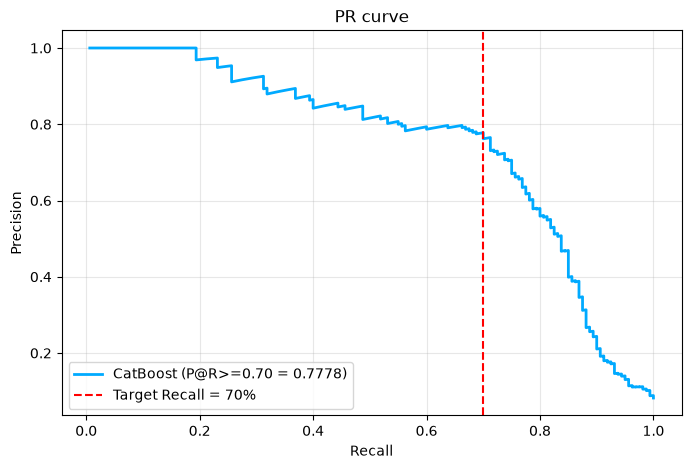

In [42]:
precisions, recalls = pr_curve(y_val, val_preds)

plt.figure(figsize=(8, 5))
plt.plot(
    recalls,
    precisions,
    label=f"CatBoost (P@R>=0.70 = {val_p_at_r:.4f})",
    color="#00aaff",
    lw=2,
)
plt.axvline(x=0.70, color="red", linestyle="--", label="Target Recall = 70%")
plt.title("PR curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 6.3. Визуализация feature importance

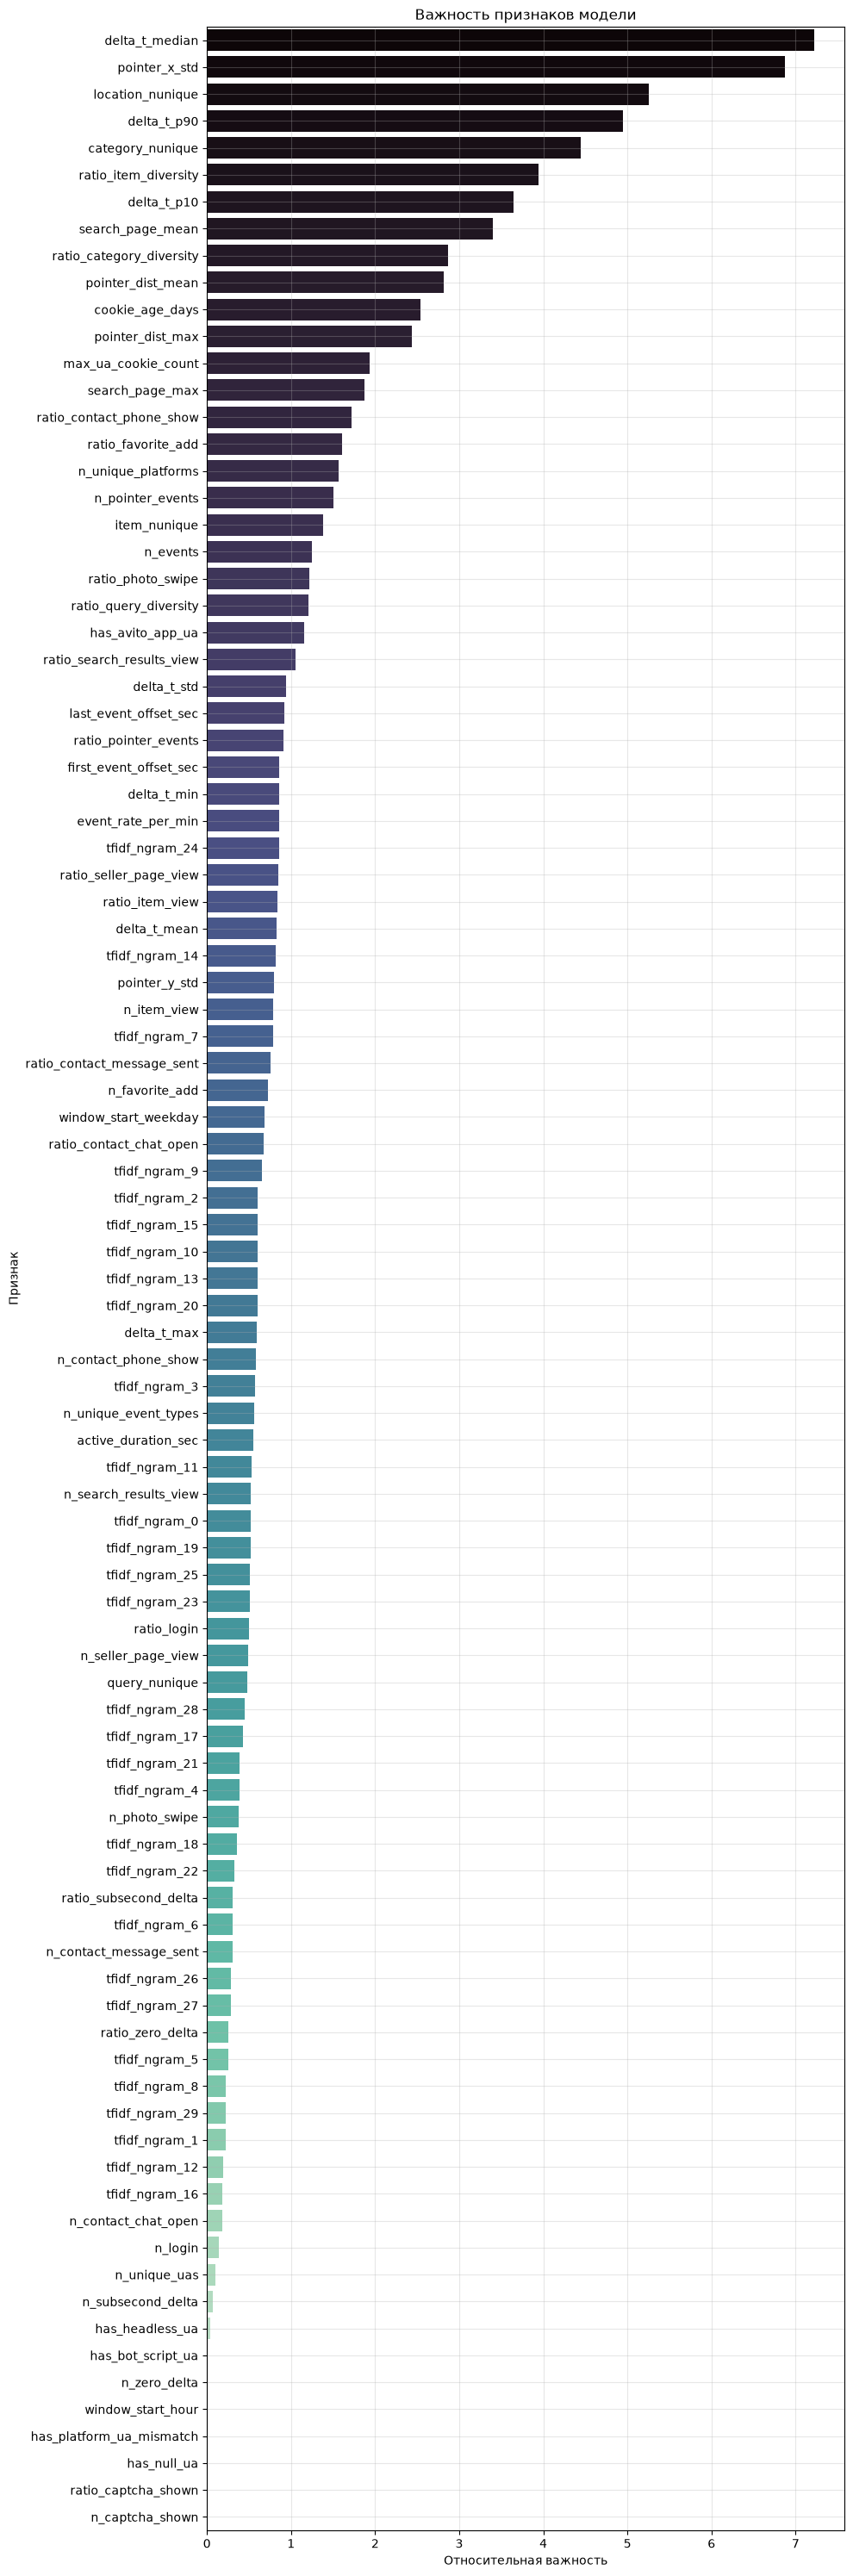

In [43]:
importance_df = pd.DataFrame(
    {"feature": feature_cols, "importance": cb_model.get_feature_importance()}
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 30))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    palette="mako",
    legend=False,
)
plt.title("Важность признаков модели")
plt.xlabel("Относительная важность")
plt.ylabel("Признак")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Анализ важности признаков обученного CatBoost подтверждает исходные предположения и демонстрирует вклад каждого из сформированных блоков:

1. **Сессионная динамика:** признаки этого блока стали фундаментальными. Абсолютным лидером всего рейтинга важности оказалась медиана задержек между событиями, а 90-й и 10-й перцентили также вошли в топ-7. Это доказывает гипотезу о неестественном темпе парсеров: автоматизированные скрипты выдают строго фиксированные интервалы или неестественно плотный поток запросов


2. **User-Agent и характеристики окружения:** из технических сигнатур наибольший вклад внес признак `max_ua_cookie_count` - популярность User-Agent среди кук, занявший 12-е место, а также разнообразие платформ. Модель научилась выявлять массовое переиспользование типовых конфигураций разными сессиями. В то же время прямые эвристики вроде `has_bot_script_ua`, `has_headless_ua` и `has_platform_ua_mismatch` получили околонулевую важность: современные краулеры маскируют заголовки под реальные браузеры, поэтому модель опиралась на поведение, а не на легко подделываемые строки ua


3. **Поведенческие паттерны и разнообразие контента:** блок показал высокую информативность: число уникальных локаций (`location_nunique`, топ-3), разнообразие просмотренных объявлений на событие (`ratio_item_diversity`, топ-5) и категорий (`category_nunique`, топ-6) - расположились на вершине графика. В отличие от живого пользователя, сфокусированного на конкретном товаре/городе, парсеры сканируют листинги широким охватом. Также существенный вес получили паттерны пагинации поисковой выдачи (`search_page_mean`, `search_page_max`) и доли целевых конверсионных действий (`ratio_contact_phone_show`, `ratio_photo_swipe`)


4. **Движение курсора мыши:** гипотеза о физике взаимодействия с интерфейсом оправдалась: признак стандартного отклонения курсора по оси X (`pointer_x_std`) стал вторым по важности во всей модели. Кроме того, в верхней части таблицы закрепились метрики перемещения мыши `pointer_dist_mean` и `pointer_dist_max`. Для веб-сессий отсутствие изменений координат служат для модели безошибочным признаком автоматизации


5. **N-граммы цепочек событий через TF-IDF:** признаки последовательностей (`tfidf_ngram_24`, `tfidf_ngram_14`, `tfidf_ngram_9`, `tfidf_ngram_3`) продемонстрировали стабильную среднюю важность в середине распределения. Они выступили надежным вспомогательным сигналом, позволяющим модели улавливать циклические программные переходы (например, циклы "поиск => просмотр => пагинация"), недоступные простым счетчикам событий

Качество champion catboost модели ($P@R = 0.7778$) сформировано за счет правильного feature engineeing исходных данных. Модель научилась детектировать ботов с должным качеством

### 6.4. Формирование submission.csv

In [44]:
X_full = df_train[feature_cols]
y_full = df_train["target"].values
X_test = df_test[feature_cols]

final_params = {
    **champion_params,
    "eval_metric": "Logloss",
    "random_seed": RANDOM_STATE,
    "verbose": 0,
}

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_full, y_full)

CatBoostClassifier(depth=8, eval_metric='Logloss', iterations=1100, l2_leaf_reg=8.190033888733076, learning_rate=0.01, random_seed=42, scale_pos_weight=1.0210181733063444, verbose=0)

In [45]:
test_scores = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"cookie_id": df_test["cookie_id"], "score": test_scores})

In [46]:
assert len(submission) == len(df_test), f"Длина {len(submission)} != {len(df_test)}"
assert submission["cookie_id"].nunique() == len(submission), (
    "Дубликаты cookie_id в сабмите!"
)
assert (submission["cookie_id"] == df_test["cookie_id"]).all(), (
    "Порядок cookie_id нарушен!"
)
assert submission["score"].between(0.0, 1.0).all(), (
    "Значения вероятностей за пределами [0, 1]!"
)
assert submission["score"].isna().sum() == 0, "Обнаружены пропущенные значения NaN!"

submission.to_csv("submission.csv", index=False)

print(submission.shape)
submission.head(10)

(4909, 2)


,cookie_id,score
0,ck_315fb710a0e371e7,0.001558
1,ck_a76ee3b3e3e522fd,0.095333
2,ck_94c9a4d382689e82,0.048070
3,ck_8eaf9509ad9462a0,0.001988
4,ck_9a88a5a989cb5bc6,0.011970
5,ck_15239ef0689c1a35,0.021615
6,ck_8de69cd219d3b87f,0.211003
7,ck_f92cd37022b0ce21,0.021955
8,ck_1a3ff7620580a514,0.019412
9,ck_397c03aa33a57310,0.229534
